# Notebook 05 — Espectros e pré-processamento


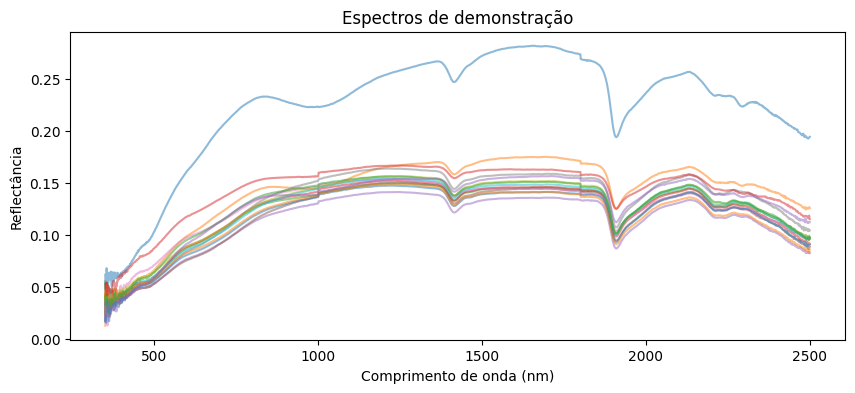

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
CANDIDATE_FILES = [
    "raw_nir_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_mir_data_saturin.csv",
]


def resolve_dataset():
    for file_name in CANDIDATE_FILES:
        candidate = DATA_DIR / file_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Arquivo espectral não encontrado em {DATA_DIR}")


def read_csv_robust(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {file_path.name}")


if 'df' not in globals():
    df = read_csv_robust(resolve_dataset())

# Descarta colunas vazias e mantém apenas colunas numéricas de comprimento de onda.
df = df.drop(columns=[c for c in df.columns if str(c).lower().startswith("unnamed")], errors="ignore")
wave_columns = []
for column in df.columns:
    try:
        value = float(str(column).strip().replace(",", "."))
    except (TypeError, ValueError):
        continue
    if 300 <= value <= 4000:
        wave_columns.append(column)

if not wave_columns:
    raise ValueError("Nenhuma coluna espectral numérica foi encontrada no arquivo carregado.")

spectra = df[wave_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
w = np.array([float(str(col).strip().replace(",", ".")) for col in wave_columns], dtype=float)

plt.figure(figsize=(10, 4))
plt.plot(w, spectra[:15].T, alpha=0.5)
plt.xlabel("Comprimento de onda (nm)")
plt.ylabel("Reflectância")
plt.title("Espectros de demonstração")
plt.show()


In [5]:
# Normalização por espectro (exemplo didático)
if 'spectra' not in globals():
    raise NameError("'spectra' não foi definido. Execute a célula anterior antes desta.")


Xn = spectra / np.maximum(np.linalg.norm(spectra, axis=1, keepdims=True), 1e-12)
print(Xn.shape)

(40137, 2151)


Pré-processamento detalhado dos espectros 

Etapas concluídas:
1. Original:              (40137, 2151)
2. Limpeza/interpolação:  (40137, 2151)
3. Suavização:            Savitzky-Golay (janela=15, polinômio=2)
4. Detrend:               (40137, 2151)
5. SNV:                   média=0.000000, desvio=1.000000
6. Normalização vetorial: norma média=1.000000


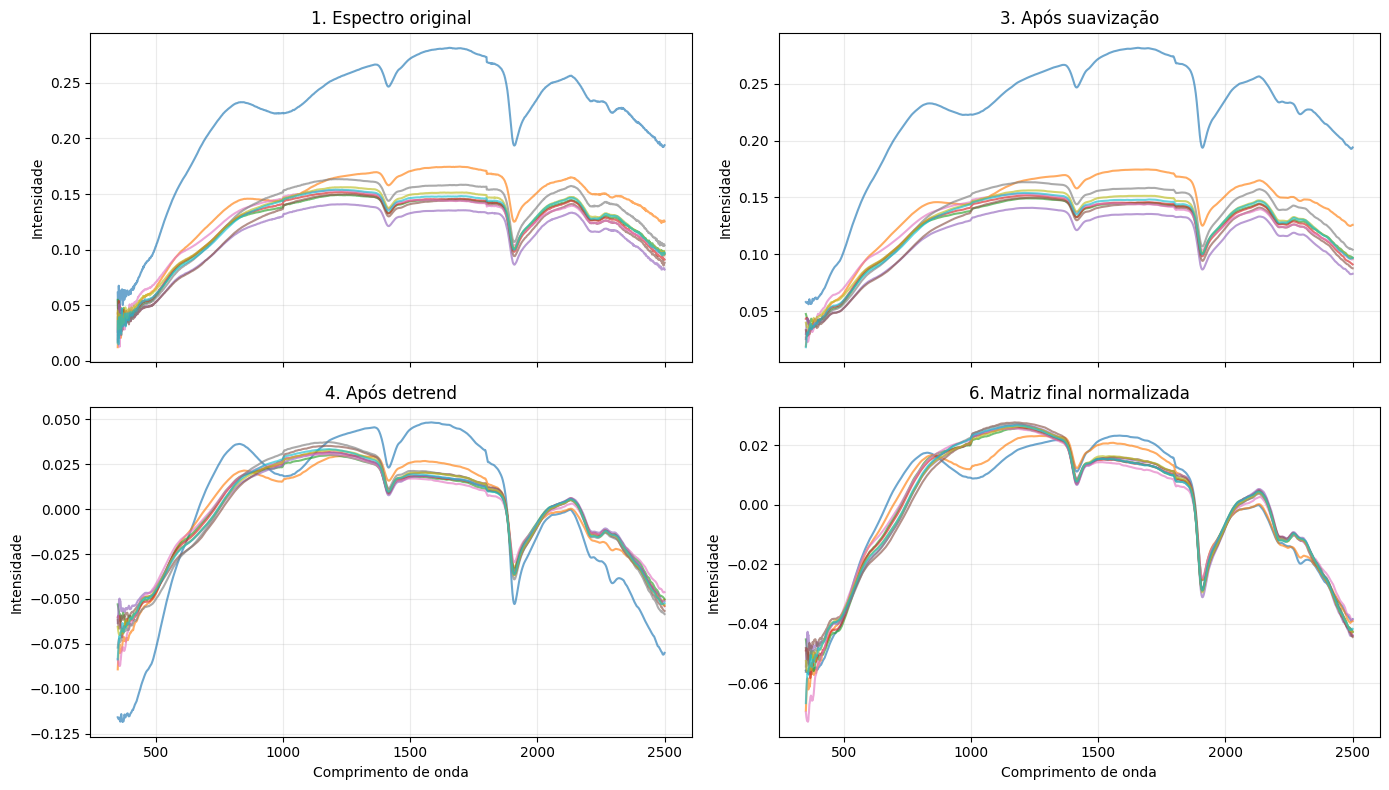

In [9]:
# Pré-processamento detalhado dos espectros
# Cada etapa gera uma matriz própria para permitir comparação e escolha do método.
import numpy as np
import matplotlib.pyplot as plt

# 1. Matriz espectral numérica
if "spectra" not in globals() or "w" not in globals():
    raise NameError("Execute a célula de carregamento dos espectros antes desta célula.")

spectra_raw = np.asarray(spectra, dtype=float).copy()
wavelengths = np.asarray(w, dtype=float)

# Garante que os comprimentos de onda estejam em ordem crescente.
order = np.argsort(wavelengths)
wavelengths = wavelengths[order]
spectra_raw = spectra_raw[:, order]

# 2. Conversão dos valores inválidos em NaN e preenchimento por interpolação.
spectra_clean = spectra_raw.copy()
spectra_clean[~np.isfinite(spectra_clean)] = np.nan

for row_index in range(spectra_clean.shape[0]):
    row = spectra_clean[row_index]
    valid = np.isfinite(row)
    if not valid.any():
        raise ValueError(f"A amostra {row_index} não possui valores espectrais válidos.")
    if valid.sum() == 1:
        row[:] = row[valid][0]
    else:
        row[:] = np.interp(
            np.arange(row.size),
            np.flatnonzero(valid),
            row[valid],
        )

# 3. Suavização Savitzky-Golay para reduzir ruído de alta frequência.
# Se scipy não estiver disponível, a matriz segue sem suavização.
spectra_smooth = spectra_clean.copy()
try:
    from scipy.signal import savgol_filter

    smoothing_window = min(15, spectra_smooth.shape[1])
    if smoothing_window % 2 == 0:
        smoothing_window -= 1
    if smoothing_window >= 5:
        spectra_smooth = savgol_filter(
            spectra_smooth,
            window_length=smoothing_window,
            polyorder=2,
            axis=1,
        )
        smoothing_status = f"Savitzky-Golay (janela={smoothing_window}, polinômio=2)"
    else:
        smoothing_status = "Não aplicado: poucas bandas espectrais"
except ImportError:
    smoothing_status = "Não aplicado: scipy não está instalado"

# 4. Correção de tendência de primeira ordem (detrend) por amostra.
# Remove o offset e a inclinação causados por espalhamento ou linha de base.
spectra_detrended = np.empty_like(spectra_smooth)
for row_index, row in enumerate(spectra_smooth):
    coefficients = np.polyfit(wavelengths, row, deg=1)
    baseline = np.polyval(coefficients, wavelengths)
    spectra_detrended[row_index] = row - baseline

# 5. SNV (Standard Normal Variate): centraliza e escala cada espectro individualmente.
row_mean = spectra_detrended.mean(axis=1, keepdims=True)
row_std = spectra_detrended.std(axis=1, keepdims=True)
spectra_snv = (spectra_detrended - row_mean) / np.maximum(row_std, 1e-12)

# 6. Normalização pelo módulo do vetor para comparar a forma dos espectros.
spectra_norm = spectra_snv / np.maximum(
    np.linalg.norm(spectra_snv, axis=1, keepdims=True),
    1e-12,
)

# Matriz final recomendada para a modelagem.
spectra_preprocessed = spectra_norm

print("Etapas concluídas:")
print(f"1. Original:              {spectra_raw.shape}")
print(f"2. Limpeza/interpolação:  {spectra_clean.shape}")
print(f"3. Suavização:            {smoothing_status}")
print(f"4. Detrend:               {spectra_detrended.shape}")
print(f"5. SNV:                   média={spectra_snv.mean(axis=1).mean():.6f}, desvio={spectra_snv.std(axis=1).mean():.6f}")
print(f"6. Normalização vetorial: norma média={np.linalg.norm(spectra_norm, axis=1).mean():.6f}")

# Comparação visual das etapas principais para as primeiras amostras.
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
plot_data = [
    (spectra_raw, "1. Espectro original"),
    (spectra_smooth, "3. Após suavização"),
    (spectra_detrended, "4. Após detrend"),
    (spectra_preprocessed, "6. Matriz final normalizada"),
]
for axis, (matrix, title) in zip(axes.ravel(), plot_data):
    axis.plot(wavelengths, matrix[:10].T, alpha=0.65)
    axis.set_title(title)
    axis.set_ylabel("Intensidade")
    axis.grid(alpha=0.25)
axes[-1, 0].set_xlabel("Comprimento de onda")
axes[-1, 1].set_xlabel("Comprimento de onda")
plt.tight_layout()
plt.show()


Full-spectrum prediction workflow (Carbon)

Target: C_gkg
R²: 0.1530
MAE: 15.5553
RMSE: 32.9452

Preview das previsões:


,C_gkg,C_gkg_pred,residual
0,12.9,29.731292,-16.831292
1,11.3,28.549440,-17.249440
2,17.4,28.496592,-11.096592
3,17.8,28.684998,-10.884998
4,16.6,29.507949,-12.907949


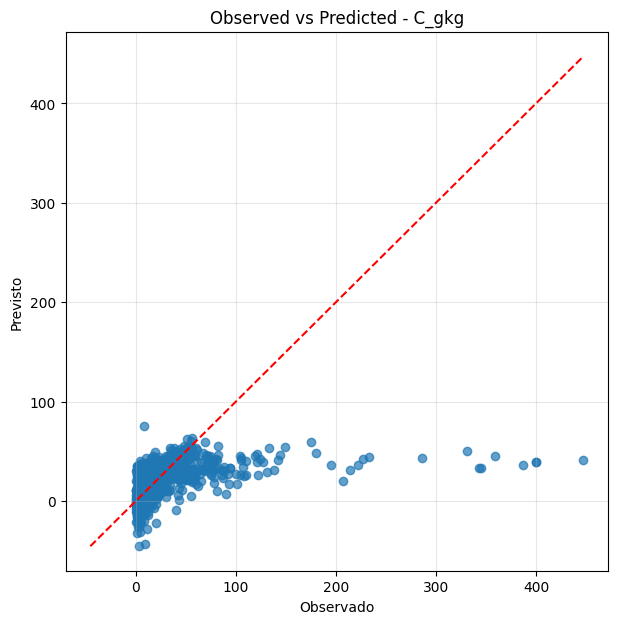


Previsão para a amostra 0: 29.7313 C_gkg


In [6]:
# Full-spectrum prediction workflow
# This cell loads the dataset, builds the full spectral matrix, trains a PLS regression model,
# evaluates it with train/test split, and predicts the target for the full dataset.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cross_decomposition import PLSRegression

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
CANDIDATE_FILES = [
    "raw_nir_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_mir_data_saturin.csv",
]


def resolve_dataset():
    for file_name in CANDIDATE_FILES:
        candidate = DATA_DIR / file_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Arquivo espectral não encontrado em {DATA_DIR}")


def read_csv_robust(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {file_path.name}")


df = read_csv_robust(resolve_dataset())

# Remove colunas de metadados vazias
for col in [c for c in df.columns if str(c).lower().startswith("unnamed")]:
    df = df.drop(columns=[col], errors="ignore")

# Detect spectral columns by wavelength-like names
wave_columns = []
for column in df.columns:
    try:
        value = float(str(column).strip().replace(",", "."))
    except (TypeError, ValueError):
        continue
    if 300 <= value <= 4000:
        wave_columns.append(column)

if not wave_columns:
    raise ValueError("Nenhuma coluna espectral numérica foi encontrada no arquivo carregado.")

X = df[wave_columns].apply(pd.to_numeric, errors="coerce")

# Escolha a variável alvo (ajuste conforme seu objetivo)
TARGET_NAME = "C_gkg"
target_candidates = [
    "C_gkg", "C", "carbono", "OM_gkg", "MO", "Clay_gkg", "Sand_gkg", "Silt_gkg"
]

target_col = next((col for col in target_candidates if col in df.columns), None)
if target_col is None:
    raise ValueError("Nenhuma coluna de alvo adequada foi encontrada no DataFrame.")

TARGET_NAME = target_col
y = pd.to_numeric(df[target_col], errors="coerce")

# Eliminar linhas com dados ausentes
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

# Preencher qualquer valor restante por mediana
X = X.fillna(X.median(numeric_only=True))
y = y.fillna(y.median())

# Split treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Standardize features for PLS
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# PLS regression is a common full-spectrum model for soil spectroscopy
pls = PLSRegression(n_components=min(10, min(X_train_s.shape) - 1), scale=False)
pls.fit(X_train_s, y_train)

# Predict on test set
pred = pls.predict(X_test_s).ravel()

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"Target: {TARGET_NAME}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Predict for the full dataset after scaling
X_all_s = scaler.transform(X)
full_pred = pls.predict(X_all_s).ravel()

results = pd.DataFrame({
    TARGET_NAME: y.values,
    f"{TARGET_NAME}_pred": full_pred,
    "residual": y.values - full_pred,
})

print("\nPreview das previsões:")
display(results.head())

# Scatter plot: observed vs predicted
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.7)
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5)
plt.xlabel("Observado")
plt.ylabel("Previsto")
plt.title(f"Observed vs Predicted - {TARGET_NAME}")
plt.grid(alpha=0.3)
plt.show()

# Example: predict a single sample from the full spectrum
sample = X.iloc[[0]].copy()
sample_s = scaler.transform(sample)
pred_sample = pls.predict(sample_s)[0]
print(f"\nPrevisão para a amostra 0: {pred_sample:.4f} {TARGET_NAME}")
